# Project Title

#Comparative Analysis of Airbnb Market Trends:Bangalore vs Mumbai

# Domain
This project belongs to the domain of Data Analytics with applications in Real Estate and Travel & Hospitality analytics,focusing on market pricing behavior and demand patterns

# Objective

1. To perform an exploratory data analysis (EDA) and comparative study of Airbnb listings in Bangalore and Mumbai

2. To uncover insights into pricing patterns,availability,customer preferences and host behavior

3. To identify key factors influencing listing prices and occupancy

4. To compare market dynamics between the two cities

# Outcome

The project helps to identify trends,demand patterns,host behavior and hidden insights from the dataset. The analysis derived actionable insights on factors affecting price and availability to support data-driven decision-making.

# Dataset Information

Source: Doorstep Analytics

Year / Timeline: Data collected on 2025

Dataset Description
1. Location: The primary metropolitan market (Bengaluru or Mumbai), used as the main categorical variable for comparison.
2. City:A sub-region or secondary division within city.
3. Neighbourhood:The specific local area.
4. Lat: The exact Latitude coordinate used for mapping and identifying property density.
5. Lng: The exact Longitude coordinate used for mapping and identifying property density.
6. BasicNightPrice: The standard nightly rate in INR.
7. Taxes: Additional government or service fees applied to the nightly rate
8. Total_Price: A calculated feature (BasicNightPrice+Taxes ) representing the true cost to the guest and revenue for the host
9. RoomType: Categorization of the rental space (Entire Home, Private Room, or Shared Room)
10. SpaceType: Specific description of the property architecture (e.g., Apartment, Villa, or Boutique Hotel).
11. Bathrooms: The total number of bathrooms available, used to determine the luxury level of the listing
12. Bedrooms: The total number of dedicated bedrooms, a primary driver of the nightly price.
13. Beds: The count of actual sleeping arrangements provided in the listing,
14. Host_isSuperhost: A binary indicator of professional host status, used to measure the "Superhost Premium" in pricing

# Type of Analysis

Describes the current Airbnb market conditions in both cities

Explain the factors influencing pricing differences

Predicts future prices or demand using available features



# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

The objective of this project is to perform a comparative analysis of Airbnb listings across two major cities to understand differences in pricing behavior,availability, and customer preferences..

The dataset consists of Airbnb listing data from two metropolitan cities including features such as price,location,room type,availability and review metrics..

Choose dataset and explain its source, size, and features

Import libraries, load dataset

Dataset description (rows, columns, features)

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#load the datsets
bang=pd.read_csv('https://raw.githubusercontent.com/reejariyaz/Comparative-Analysis-of-Airbnb-Market-Trends-Bangalore-Mumbai/refs/heads/main/DoorstepAnalytics_Airbnb_Bengaluru_India_Overview.csv')
mum=pd.read_csv('https://raw.githubusercontent.com/reejariyaz/Comparative-Analysis-of-Airbnb-Market-Trends-Bangalore-Mumbai/refs/heads/main/DoorstepAnalytics_Airbnb_Mumbai_India_Overview.csv')

In [ ]:
#Append the two datasets together
df=pd.concat([bang,mum],ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13226 entries, 0 to 13225
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        13226 non-null  object 
 1   Location                       13226 non-null  object 
 2   Airbnb_ListingID               13226 non-null  int64  
 3   Scrape_Date                    13226 non-null  object 
 4   Lat                            13226 non-null  float64
 5   Lng                            13226 non-null  float64
 6   City                           13221 non-null  object 
 7   LocalizedCity                  13226 non-null  object 
 8   LocalizedNeighbourhood_Source  9793 non-null   object 
 9   LocalizedNeighbourhood_ML      9117 non-null   object 
 10  LocalizedNeighbourhood         9981 non-null   object 
 11  ListingTitle                   13226 non-null  object 
 12  Bathrooms                      13186 non-null 

In [ ]:

df.head()


,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,...,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,HostLanguages_Verbose,RecordInserted
0,India,Bengaluru,13183709,2025-10-31,13.021659,77.628189,Bengaluru,Bengaluru,Lingarajapura,Lingarajapura,...,NaN,NaN,NaN,NaN,NaN,0,0,False,['English' 'Hindi'],2025-10-31 02:01:53
1,India,Bengaluru,654064165740107808,2025-10-31,13.015500,77.671480,Bengaluru,Bengaluru,Ramamurthy Nagar,Ramamurthy Nagar,...,3545.40,709.08,5 nights x $40.51,40.0,8.0,0,0,False,['English' 'Hindi'],2025-10-31 02:07:21
2,India,Bengaluru,1411530165672374120,2025-10-31,12.867241,77.557969,Bengaluru,Bengaluru,NaN,NaN,...,2836.32,443.18,5 nights x $32.06,32.0,5.0,0,0,True,['Arabic' 'English' 'Hindi' 'Kannada' 'Urdu'],2025-10-31 02:07:56
3,India,Bengaluru,920610774197649433,2025-10-31,12.982720,77.704970,Bengaluru,Bengaluru,Mahadevapura,Mahadevapura,...,1772.70,443.18,5 nights x $20.31,20.0,5.0,0,0,True,['Bengali' 'English' 'Hindi'],2025-10-31 02:08:19
4,India,Bengaluru,716367382981245820,2025-10-31,12.983480,77.705840,Bengaluru,Bengaluru,Mahadevapura,Mahadevapura,...,1772.70,443.18,5 nights x $20.31,20.0,5.0,0,0,True,['Bengali' 'English' 'Hindi'],2025-10-31 02:08:23


In [ ]:

df.tail()

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,...,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,HostLanguages_Verbose,RecordInserted
13221,India,Mumbai,1389581808948528015,2025-10-29,19.128860,72.880440,Mumbai,Mumbai,Andheri East,NaN,...,20556.19,14821.63,5 nights x $233.95,233.0,168.0,0,0,True,['English' 'Hindi'],2025-10-29 05:53:56
13222,India,Mumbai,1331796873445309167,2025-10-29,19.131123,72.824684,Mumbai,Mumbai,Andheri West,Andheri West,...,4322.98,882.24,5 nights x $49.82,49.0,10.0,0,0,False,[],2025-10-29 05:54:36
13223,India,Mumbai,53055813,2025-10-29,19.079660,72.849550,Mumbai,Mumbai,Santacruz East,Santacruz East,...,15350.98,11028.00,5 nights x $174.90,174.0,125.0,0,0,False,[],2025-10-29 05:54:46
13224,India,Mumbai,1094726140998781775,2025-10-29,19.004801,72.829827,Mumbai,Mumbai,Lower Parel,Lower Parel,...,11910.24,8998.85,5 nights x $135.63,135.0,102.0,0,1,True,['English' 'Hindi'],2025-10-29 05:53:15
13225,India,Mumbai,1337596129421155238,2025-10-29,19.112336,72.838016,Mumbai,Mumbai,Ville Parle West,Ville Parle West,...,3087.84,617.57,5 nights x $35.27,35.0,7.0,0,0,False,[],2025-10-29 05:54:39


In [ ]:

df.describe()


,Airbnb_ListingID,Lat,Lng,Bathrooms,Bedrooms,Beds,MaxGuests,Host_ID,isHomeOrServicedApartment,PictureCount,ReviewCount,ReviewScore,StarRating,BasicNightPrice,Taxes,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc
count,1.322600e+04,13226.000000,13226.000000,13186.000000,13174.000000,13191.000000,13226.000000,1.322600e+04,13226.000000,13226.000000,13226.000000,7437.000000,7447.000000,12701.000000,12541.000000,12701.000000,12541.000000,13226.000000,13226.000000
mean,1.018637e+18,14.900869,76.120689,1.639087,1.653029,2.018573,3.802737,3.473174e+08,0.635944,8.389082,17.398609,4.674385,4.716219,5244.096915,2396.448279,59.285096,27.094490,0.022758,0.030546
std,5.188617e+17,2.854215,2.222771,1.755579,2.022064,2.716814,2.787229,2.215514e+08,0.481183,13.570968,34.852237,0.361298,0.420766,12125.760750,9922.363214,137.004452,112.120119,0.149137,0.172090
min,1.332000e+04,12.800650,72.783400,0.000000,0.000000,0.000000,1.000000,1.965400e+04,0.000000,0.000000,0.000000,1.500000,0.000000,354.540000,88.220000,4.000000,1.000000,0.000000,0.000000
25%,8.048692e+17,12.921627,72.873323,1.000000,1.000000,1.000000,2.000000,1.507255e+08,0.000000,0.000000,0.000000,4.560000,4.500000,2038.610000,354.540000,23.000000,4.000000,0.000000,0.000000
50%,1.211341e+18,13.017075,77.602865,1.000000,1.000000,1.000000,3.000000,3.446852e+08,1.000000,0.000000,4.000000,4.780000,5.000000,3176.060000,620.450000,36.000000,7.000000,0.000000,0.000000
75%,1.424936e+18,19.064059,77.643644,2.000000,2.000000,2.000000,4.000000,5.444187e+08,1.000000,13.000000,19.000000,4.910000,5.000000,5672.640000,1235.140000,64.000000,14.000000,0.000000,0.000000
max,1.542773e+18,19.210570,77.753628,50.000000,50.000000,81.000000,16.000000,7.260963e+08,1.000000,181.000000,686.000000,5.000000,5.000000,957878.450000,720336.650000,10807.000000,8127.000000,1.000000,1.000000


In [ ]:

df.shape

(13226, 44)

In [ ]:
df.columns

Index(['Country', 'Location', 'Airbnb_ListingID', 'Scrape_Date', 'Lat', 'Lng',
       'City', 'LocalizedCity', 'LocalizedNeighbourhood_Source',
       'LocalizedNeighbourhood_ML', 'LocalizedNeighbourhood', 'ListingTitle',
       'Bathrooms', 'Bedrooms', 'Beds', 'MaxGuests', 'Host_ID',
       'Host_FirstName', 'Host_isSuperhost', 'isNewListing', 'isSuperhost',
       'RoomType', 'RoomType_Clean', 'SpaceType', 'SpaceType_Clean',
       'isHomeOrServicedApartment', 'PictureCount', 'ReviewCount',
       'ReviewScore', 'StarRating', 'isLimitedAirbnbData',
       'BasicNightPrice_CheckIn', 'BasicNightPrice_CheckOut', 'Currency',
       'BasicNightPrice', 'Taxes', 'BasicNightPriceString_USD',
       'BasicNightPrice_USD', 'Taxes_USD', 'isOverpricedPerBeds_Calc',
       'isOverpricedPerGuest_Calc', 'Amenities_SelfCheckIn',
       'HostLanguages_Verbose', 'RecordInserted'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Country,0
Location,0
Airbnb_ListingID,0
Scrape_Date,0
Lat,0
Lng,0
City,5
LocalizedCity,0
LocalizedNeighbourhood_Source,3433
LocalizedNeighbourhood_ML,4109


In [ ]:
df.duplicated().sum()

np.int64(0)

## Stage 2 – Data Cleaning and Pre-processing


The dataset initially contained multiple redundant and irrelevant columns,including identifiers,duplicate location fields,and columns with a high percentage of missing values.These were removed to improve data quality and focus the analysis on key variables such as pricing,location,and listing characteristics

The city column had different formats and languages like Hindi.So, I converted all values into standard names like Bengaluru and Mumbai to make the data consistent.

**Standardize all variations of city**

In [ ]:
diff=df[df['City']!=df['LocalizedCity']]
print(diff[['City','LocalizedCity']])
df.loc[(df['City'].str.contains('Bang|Beng',case=False,na=False))|
(df['LocalizedCity'].str.contains('Bang|Beng|Kar',case=False,na=False)),'City']='Bengaluru'
df.loc[(df['City'].str.contains('Mumb|Mahar|मुंबई',case=False,na=False))|
 (df['LocalizedCity'].str.contains('Mumb|Mahar|मुंबई',case=False,na=False)),'City']='Mumbai'

diff=df[df['City']!=df['LocalizedCity']]
print(diff[['City','LocalizedCity']])

            City LocalizedCity
10     Bangalore     Bengaluru
51     Bangalore     Bengaluru
186    Bangalore     Bengaluru
190    Bangalore     Bengaluru
266     Banglore     Bengaluru
...          ...           ...
12529    Mumbai         Mumbai
12687    Mumbai         Mumbai
12832    Mumbai         Mumbai
13077      मुंबई        Mumbai
13091      मुंबई        Mumbai

[213 rows x 2 columns]
                 City          LocalizedCity
741         Bengaluru     Bangalore Division
914         Bengaluru  Doddagubbi, Bengaluru
920    Byrasettihalli        Byrashettihalli
1012        Bengaluru             Bangalore 
1029        Bengaluru     Bangalore Division
...               ...                    ...
11986          Mumbai            Maharashtra
12053          Mumbai    Andheri East Mumbai
12186          Mumbai            Mumbai City
12887          Mumbai            West Mumbai
13212          Mumbai            West Mumbai

[71 rows x 2 columns]


**Interpretation**
* This step addresses inconsistencies in the geographical data by standardizing various naming conversions for cities.

In [ ]:
df['City'].isnull().sum()

np.int64(1)

In [ ]:
df[df['City'].isna()]

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,...,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,HostLanguages_Verbose,RecordInserted
7874,India,Bengaluru,1000401950324673248,2025-10-31,13.18275,77.63596,NaN,IN,NaN,NaN,...,5229.47,974.99,5 nights x $59.76,59.0,11.0,0,0,True,['English' 'Hindi'],2025-10-31 02:07:32


In [ ]:
df.loc[
    df['City'].isna()&
    df['LocalizedNeighbourhood'].isna()&
    df['Location'].str.contains('Bengaluru',case=False,na=False),
    'City']='Bengaluru'

We filled the null values in the 'City' column using the 'Location' data.

**Removed unnecessary columns**

In [ ]:
df=df.drop(['Country','Airbnb_ListingID','Scrape_Date','LocalizedCity','LocalizedNeighbourhood_Source','LocalizedNeighbourhood_ML',
            'ListingTitle','MaxGuests','Host_FirstName','Host_isSuperhost','RoomType_Clean','SpaceType_Clean','PictureCount',
            'ReviewCount','ReviewScore','StarRating','isLimitedAirbnbData','BasicNightPrice_CheckIn','BasicNightPrice_CheckOut',
            'Currency','BasicNightPriceString_USD','BasicNightPrice_USD','Taxes_USD','isOverpricedPerBeds_Calc','isOverpricedPerGuest_Calc',
            'Amenities_SelfCheckIn','HostLanguages_Verbose','RecordInserted'],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13226 entries, 0 to 13225
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   13226 non-null  object 
 1   Lat                        13226 non-null  float64
 2   Lng                        13226 non-null  float64
 3   City                       13226 non-null  object 
 4   LocalizedNeighbourhood     9981 non-null   object 
 5   Bathrooms                  13186 non-null  float64
 6   Bedrooms                   13174 non-null  float64
 7   Beds                       13191 non-null  float64
 8   Host_ID                    13226 non-null  int64  
 9   isNewListing               13206 non-null  object 
 10  isSuperhost                13226 non-null  bool   
 11  RoomType                   13226 non-null  object 
 12  SpaceType                  13226 non-null  object 
 13  isHomeOrServicedApartment  13226 non-null  int

This step involves the strategic removal of columns that do not contribute to the analytical goals of the project.By filtering out,the dataset becomes more focused and manageable.

**Handling Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(125)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

Removing these duplicates ensures that datasets are cleaned,accurate and non repititive data.

**Handling Missing Values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13101 entries, 0 to 13225
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   13101 non-null  object 
 1   Lat                        13101 non-null  float64
 2   Lng                        13101 non-null  float64
 3   City                       13101 non-null  object 
 4   LocalizedNeighbourhood     9901 non-null   object 
 5   Bathrooms                  13061 non-null  float64
 6   Bedrooms                   13049 non-null  float64
 7   Beds                       13066 non-null  float64
 8   Host_ID                    13101 non-null  int64  
 9   isNewListing               13081 non-null  object 
 10  isSuperhost                13101 non-null  bool   
 11  RoomType                   13101 non-null  object 
 12  SpaceType                  13101 non-null  object 
 13  isHomeOrServicedApartment  13101 non-null  int64  


In [ ]:
df['LocalizedNeighbourhood']=df['LocalizedNeighbourhood'].fillna('Unknown')
df.loc[
    (df['Location']=='Bengaluru') & (df['LocalizedNeighbourhood']=='Unknown'),
    'LocalizedNeighbourhood']='Unknown-Bengaluru'
df.loc[
    (df['Location']=='Mumbai') & (df['LocalizedNeighbourhood']=='Unknown'),
    'LocalizedNeighbourhood']='Unknown-Mumbai'

Missing values in the neighbourhood column were standardized as 'Unknown' and further categorized into city specific labels to preserve geographic integrity and improve comparative analysis between cities.

In [ ]:
df['Bathrooms']=df['Bathrooms'].fillna(df['Bathrooms'].median())
df['Bedrooms']=df['Bedrooms'].fillna(df['Bedrooms'].median())
df['Beds']=df['Beds'].fillna(df['Beds'].median())

This step addresses missing values in key listing characteristics of bathrooms,bedrooms, and beds by imputing them with the median value of each respective column.

In [ ]:
df['isNewListing']=df['isNewListing'].fillna(False)
print(df['isNewListing'].value_counts())

isNewListing
False    11823
True      1278
Name: count, dtype: int64


/tmp/ipykernel_9639/1852730434.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['isNewListing']=df['isNewListing'].fillna(False)


In the isNewListing column,usually most listings on the platform are not brand new,so False is the most likely value.

**Treating Outliers**

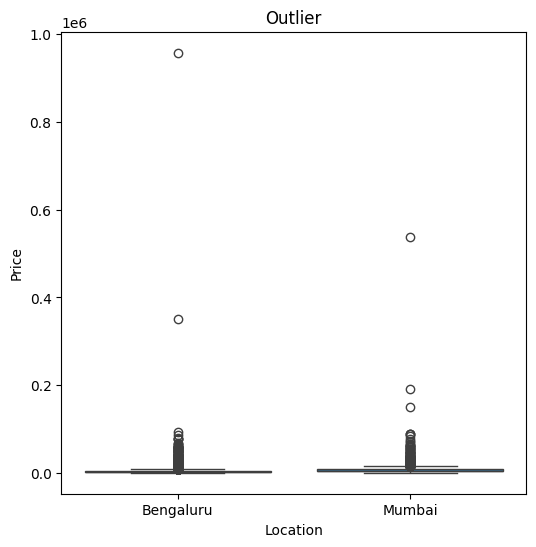

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Location',y='BasicNightPrice',data=df)
plt.title('Outlier')
plt.ylabel('Price')
plt.show()

In [ ]:
#Checking Skewness
df['BasicNightPrice'].skew()

np.float64(47.66836915380343)

Treating outlier using IQR method

In [ ]:
cleaned_data=[]
for Location in df['Location'].unique():
  city_data=df[df['Location']==Location]
  Q1=city_data['BasicNightPrice'].quantile(0.25)
  Q3=city_data['BasicNightPrice'].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR

  print(f'Q1:{Q1},Q3:{Q3},IQR:{IQR}')
  print(f'The cut off for Outliers is:{upper_bound}')

  city_clean=city_data[(city_data['BasicNightPrice']>= lower_bound) &
                       (city_data['BasicNightPrice']<=upper_bound)]
  print(f'Original Rows:{len(city_data)}')
  print(f'Rows after IQR cleaning:{len(city_clean)}')

  cleaned_data.append(city_clean)
clean_df=pd.concat(cleaned_data)

Q1:1772.7,Q3:4165.85,IQR:2393.1500000000005
The cut off for Outliers is:7755.575000000001
Original Rows:8964
Rows after IQR cleaning:7763
Q1:3528.96,Q3:8204.83,IQR:4675.87
The cut off for Outliers is:15218.635
Original Rows:4137
Rows after IQR cleaning:3673


In [ ]:
#checking skewness after outliers removed
clean_df['BasicNightPrice'].skew()

np.float64(1.6814020963670857)

After Outlier Box PLot

<Axes: xlabel='Location', ylabel='BasicNightPrice'>

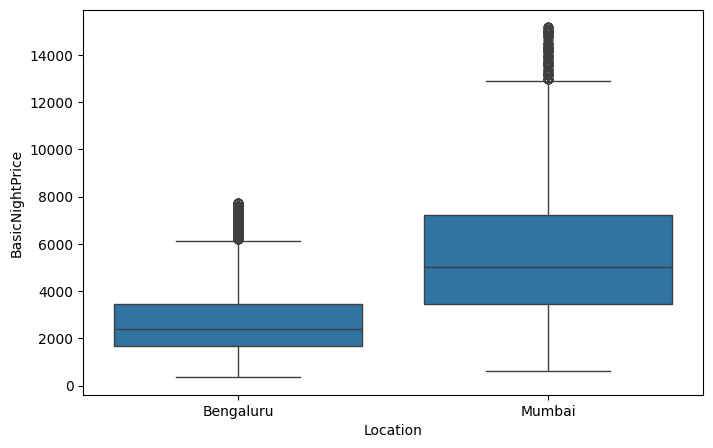

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df,x='Location',y='BasicNightPrice')

Outliers were removed using the IQR method applied seperately for each city.The cleaned dataset was then used to visualize the distribution for accurate comparison of pricing between Bengaluru and Mumbai.

In [ ]:
#Bengaluru Median
blr_median=df[df['Location']=='Bengaluru']['BasicNightPrice'].median()
#Mumbai Median
mum_median=df[df['Location']=='Mumbai']['BasicNightPrice'].median()

print(f'Remaining Nulls in BasicNightPrice of Bengaluru:{df[(df['Location']=='Bengaluru')]['BasicNightPrice'].isnull().sum()}')
df.loc[(df['Location']=='Bengaluru')&(df['BasicNightPrice'].isna()),'BasicNightPrice']=blr_median
print(f'Every missing price has been filled with the Bengaluru median:{blr_median}')

print(f'Remaining Nulls in BasicNightPrice of Mumbai:{df[(df['Location']=='Mumbai')]['BasicNightPrice'].isnull().sum()}')
df.loc[(df['Location']=='Mumbai')&(df['BasicNightPrice'].isna()),'BasicNightPrice']=mum_median
print(f'Every missing price has been filled with the Bengaluru median:{mum_median}')

Remaining Nulls in BasicNightPrice of Bengaluru:341
Every missing price has been filled with the Bengaluru median:2481.78
Remaining Nulls in BasicNightPrice of Mumbai:177
Every missing price has been filled with the Bengaluru median:5337.549999999999


Missing values in the BasicNightPrice column were imputed using the median value calculated at the city level.

In [ ]:
clean_df['Taxes']=clean_df['Taxes'].fillna(0)

**Adding new column**

In [ ]:

clean_df['Total_Price']=clean_df['BasicNightPrice']+clean_df['Taxes']

A new feature,Total_Price was created by combining the BasicNightPrice and applicable taxes to represent the overall cost of a stay.

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11436 entries, 1 to 13225
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   11436 non-null  object 
 1   Lat                        11436 non-null  float64
 2   Lng                        11436 non-null  float64
 3   City                       11436 non-null  object 
 4   LocalizedNeighbourhood     11436 non-null  object 
 5   Bathrooms                  11436 non-null  float64
 6   Bedrooms                   11436 non-null  float64
 7   Beds                       11436 non-null  float64
 8   Host_ID                    11436 non-null  int64  
 9   isNewListing               11436 non-null  bool   
 10  isSuperhost                11436 non-null  bool   
 11  RoomType                   11436 non-null  object 
 12  SpaceType                  11436 non-null  object 
 13  isHomeOrServicedApartment  11436 non-null  int64  


Now the datsets are cleaned successfully and ready for the analysis.

Uploaded the Dataset

In [ ]:

clean_df.to_csv('cleaned_dataset.csv')

Exporting the cleaned Airbnb dataset for Bengaluru and Mumbai to a CSV file

## Stage 3 – EDA and Visualizations


**Univariate Analysis**

Price Distribution

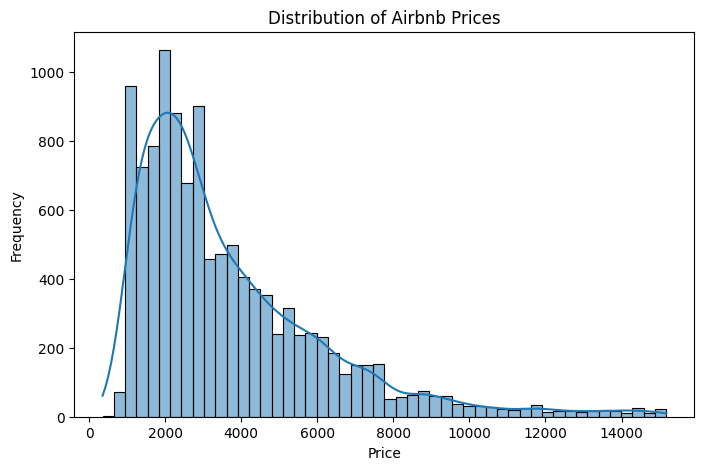

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df['BasicNightPrice'],bins=50,kde=True)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The Histogram Chart shows the price distribution of Airbnb listings

**Feature used:**BasicNightPrice represents the cost of a basic night's stay

**Interpretations:**

*  The Chart is positivel skewed,the highest peak occurs between 1500 and 2000.
*   Most listings are priced under 6000,After that frequeny drops significantly,showing that high-end rentals are much rarer.

Room Type Distribution

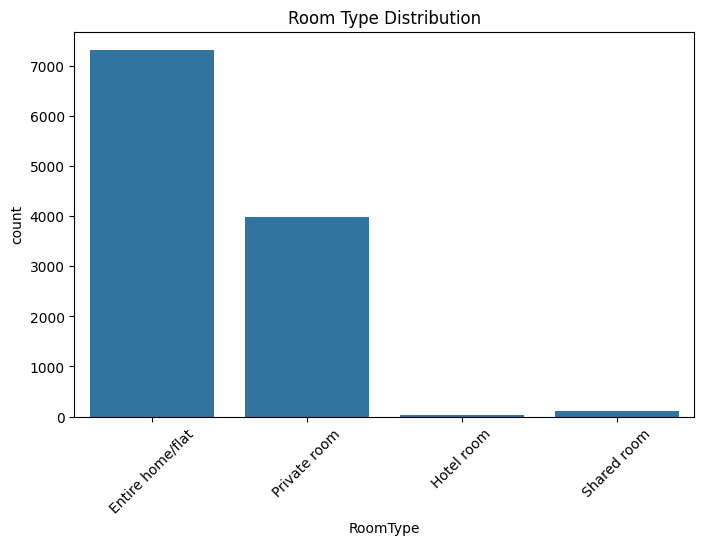

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=clean_df['RoomType'])
plt.title('Room Type Distribution')
plt.xticks(rotation=45)
plt.show()

The CountPlot Chart is used to visualize the frequency of Airbnb listings belongs to each specific room category.

**Feature used:** RoomType represents the four categories:Entire home/flat,Private room,Hotel room,Shared room.

**Interpretations:**

The Chart reveals that Entire home/flat is the most prefered category,followed by Private room.

City-wise Distribution

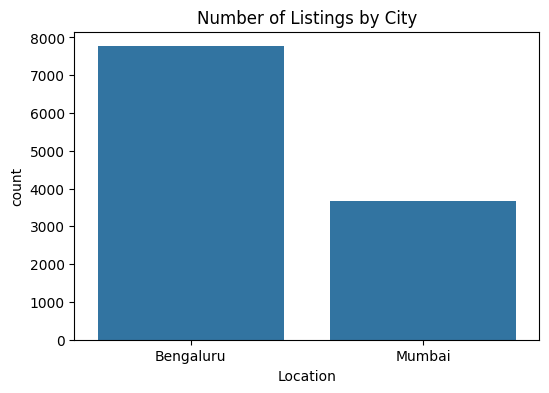

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=clean_df['Location'])
plt.title('Number of Listings by City')
plt.show()

The Bar Chart is used to visualize the distribution of Airbnb listings locations to identify which city has the highest market activity.

**Feature used:** Location represents the Bengaluru and Mumbai cities.

**Interpretations:**

Bengaluru has a significantly higher volume of listings,nearly 8000,which is nearly two times the amount found in Mumbai.It indicates much more active market in Bengaluru compared to Mumbai.

**Bivariate Analysis**

Relationship between Bedrooms and Price

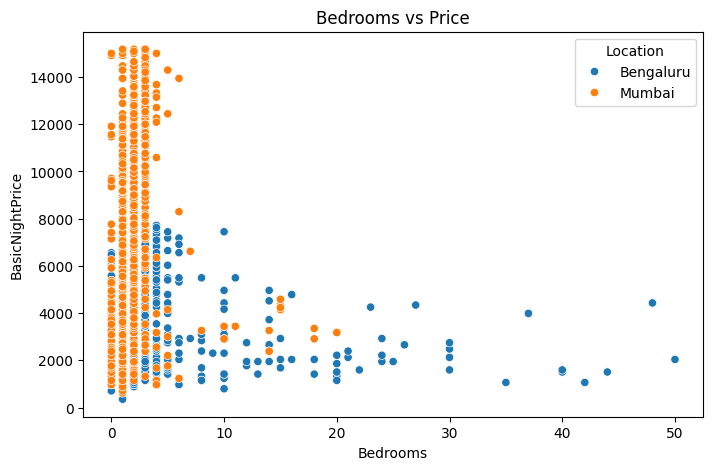

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Bedrooms',y='BasicNightPrice',hue='Location',data=clean_df)
plt.title("Bedrooms vs Price")
plt.show()

The ScatterPlot Chart is used to observe the distribution of property prices relative to the number of bedrooms.

**Feature used:**
Bedrooms represents the count of rooms.
BasicNightPrice represents the price of bedroom.

Interpretations:

The Chart reveals that Mumbai has a very high density of listings with a low bedroom count but a wide price range.In contrast,Bengaluru shows more diversity in property size,though these larger properties maintain a lower price range compared to the smaller,high end listings in Mumbai.

Average price of both cities

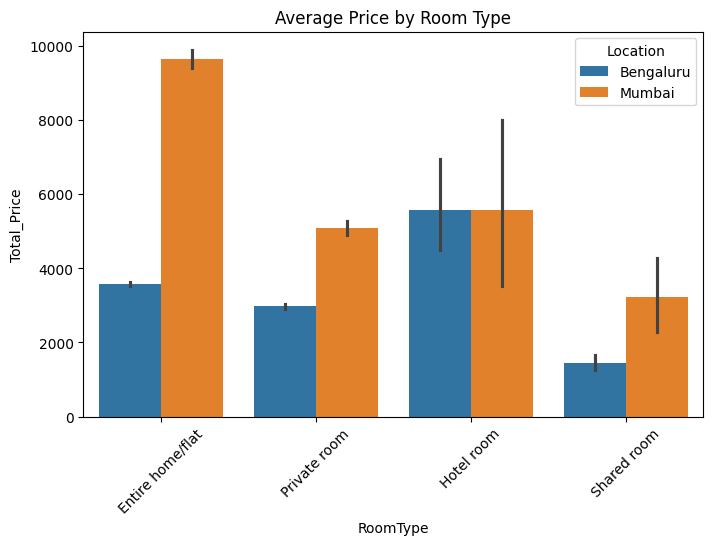

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='RoomType',y='Total_Price',hue='Location',data=clean_df.dropna(subset=['Total_Price']))
plt.title('Average Price by Room Type')
plt.xticks(rotation=45)
plt.show()

The BarPlot Chart purpose is to compare the average of Total_Price across different RoomType simultaneously comparing how these values differ between two specific Location.

**Feature used:** RoomType represents the four categories:Entire home/flat,Private room,Hotel room,Shared room.
Total_Price represents the average calculated cost.

**Interpretations:**

Mumbai consistently has higher average total prices than Bengaluru for almost all room categories,most notably for Entire home/flat where the price is more than double.Hotel rooms show the most significant price variability in both cities,suggesting that hotel pricing is much less standardized than private or shared room listings.

Correlation Heatmap

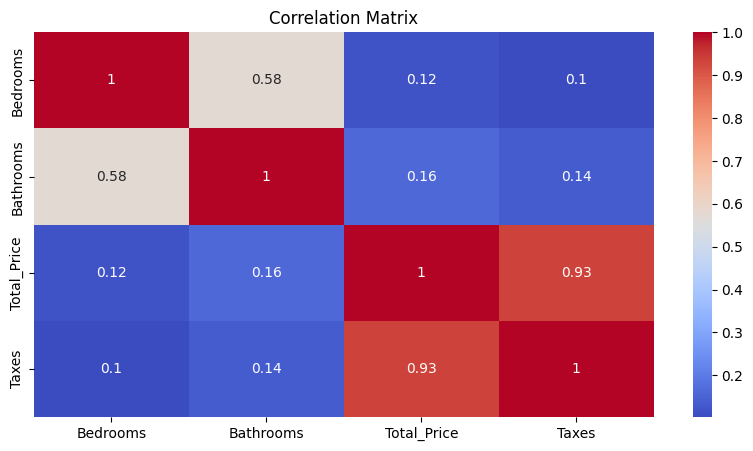

In [ ]:
plt.figure(figsize=(10,5))
corr=clean_df.dropna(subset=['Total_Price','Taxes'])[['Bedrooms','Bathrooms','Total_Price','Taxes']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
#plt.xticks(rotation=45)
plt.show()

The Correlation Heatmap is used to visualize how strongly different numerical features are related to each other after data cleaning.

**Feature used:** Bedrooms,Bathrooms,Total_Price and Taxes.

**Interpretations:**

The Chart reveals a very strong positive correlation between Total Price and Taxes,meaning they increase directly together.However there is only a week correlation between the number of rooms and the price.

Multivariate Analysis

<Figure size 800x600 with 0 Axes>

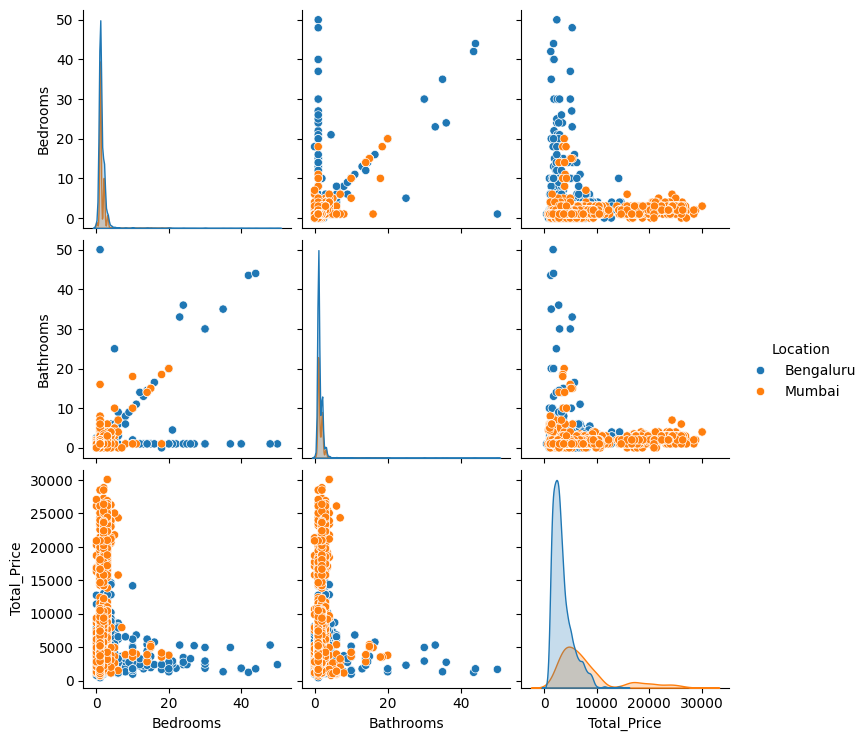

In [ ]:
plt.figure(figsize=(8,6))
plot_data=clean_df.dropna(subset=['Total_Price'])
sns.pairplot(plot_data[['Bedrooms','Bathrooms','Total_Price','Location']],hue='Location')
plt.show()

The Seaborn Pair Plot chart is used to visualize the pairwise relationships between multiple numeric variables.It color-codes the data by Location to show how these cities differ across all features at once.

**Feature used:** Bedrooms,Bathrooms,Total_Price and Location for hue.

**Interpretations:**

* Bengaluru generally has a higher frequency of lower priced listings compared to Mumbai.
* There is a strong positive correlation between the number of bedrooms and bathrooms in both cities.
* Surprisingly,a higher number of bedrooms or bathrooms does not automatically mean a higher price.Many listings with many bedrooms in Bengaluru are priced lower than smaller luxury listings.
* Bengaluru listings appear to have a wider range of property sizes,wheareas Mumbai listings are more tightly clustered in terms of size but contain competitive pricing.



Grouped Analysis-Advanced Plot

In [ ]:
pivot=clean_df.pivot_table(values='Total_Price',index='Location',columns='RoomType',aggfunc='mean')
print(pivot)

RoomType   Entire home/flat   Hotel room  Private room  Shared room
Location                                                           
Bengaluru       3567.138531  5562.735600   2978.161180  1448.300200
Mumbai          9648.277097  5563.992667   5097.807711  3218.705333


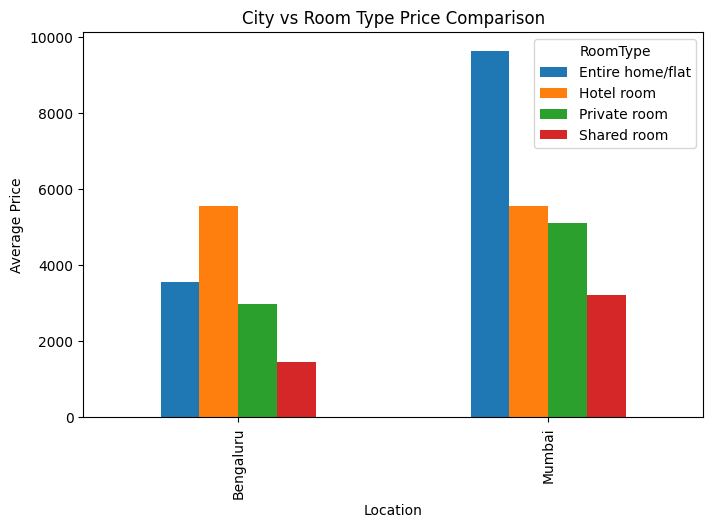

In [ ]:
pivot.plot(kind='bar',figsize=(8,5))
plt.title("City vs Room Type Price Comparison")
plt.ylabel('Average Price')
plt.show()

The Bar Chart visualizes the average price differences between Mumbai and Bengaluru across four specific room categories.

**Feature used:** Location and RoomType.

**Interpretations:**

* Mumbai is significantly more expensive than Bengaluru in every category,especially for Entirehomes/flats,which cost nearly 3 times more.
* Bengaluru's most expensive category is Hotel rooms,not entire homes.
* A Shared room in Mumbai is nearly as expensive as an Entire home in Bengaluru.
* Shared rooms in Bengaluru represent the most affordable price point for travelers.

Neighbourhood Analysis

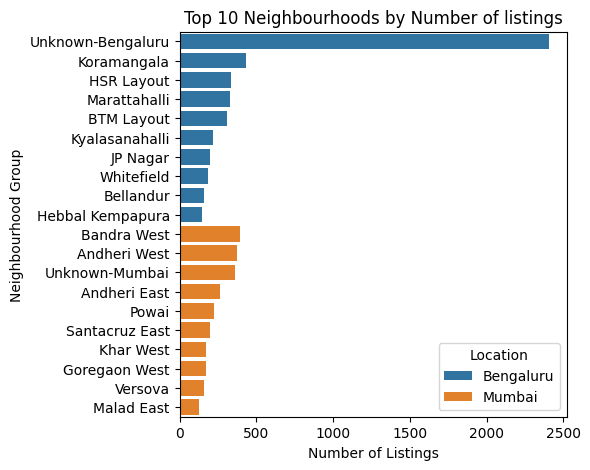

In [ ]:
from pandas.core.groupby import groupby
plt.figure(figsize=(5,5))
top10_city=(clean_df.groupby(['Location','LocalizedNeighbourhood']).size()
                                 .reset_index(name='Count')
                                 .sort_values(['Location','Count'],ascending=[True,False])
)
top10_city=top10_city.groupby('Location').head(10)

sns.barplot(data=top10_city,x='Count',y='LocalizedNeighbourhood',hue='Location')
plt.title('Top 10 Neighbourhoods by Number of listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood Group')
plt.show()

The Horizontal Bar Chart identifies the Top 10 most popular neighbourhoods based on the Airbnb listings,categorized b both cities.

**Feature used:** Location and LocalizedNeighbourhood

**Interpretations:**

* Excluding Unknown,Koramangala is the leading neighbourhood with the highest number of listings,making it a primary Airbnb hotspot in Bengaluru.
* Popular areas like HSR Layout,Maranthahalli, and BTM Layout indicating that aread is concentrated in Tech and residential Hubs.
* In Mumbai,Andheri West and Bandra West are the most prominent neighbourhoods.These are well known commercial and entertainment hubs.

In [ ]:
import pandas as pd
import plotly.express as px
fig=px.scatter_mapbox(
    clean_df,lat='Lat',lon='Lng',color='BasicNightPrice',size='BasicNightPrice',
    zoom=5,center={'lat':16.0,'lon':75.5},mapbox_style="carto-positron",size_max=20,title="Airbnb Listings Map"
)
fig.show()

The Geospatial Scatter Map used to visualize the phsical distribution of Airbnb listings across the geographical landscape of India.

**Feature used:** Latitude,Longitude,Location,BasicNightPrice.

**Interpretations:**

The color intensity indicates that higher-priced listings are spread throughout both cities.Mumbai appears to have a very dense concentration of high value points.

# **Dashboard**

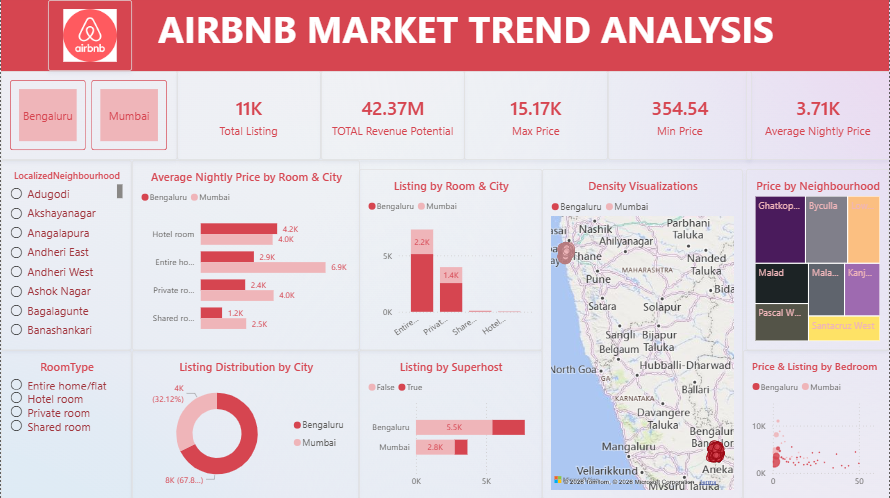

**Summary**


* The dataset contains roughly 11K listings across Bengaluru and Mumbai
making it suitable for city-level Airbnb market analysis.
* The dashboard shows Total Revenue Potential = 42.37M.
* The Average Nightly Price = 3.71K, with a Maximum Price = 15.17K and
Minimum Price = 354.54.
* Most listings are concentrated in Bengaluru, especially in areas like HSR
Layout, Koramangala, BTM Layout, Whitefield, Bellandur, Domlur,
Indira Nagar, and Marathahalli.
* The dataset includes key property attributes such as City, Neighbourhood,
Bathrooms, Bedrooms, Beds, Room Type, Space Type, Superhost status,
New listing status, BasicNightPrice, Taxes, and Total_Price.


**Key Insights**

* Entire homes/flats dominate the market, showing that guests and hosts
prefer full-property stays over shared options.
* Private rooms and shared rooms are plays a smaller role in overall market revenue.
* Revenue and pricing vary strongly by neighbourhood, with premium
localities charging much higher nightly rates than budget areas.
* Bengaluru has dense property concentration in central and tech-driven
areas, showing strong demand around business and residential hubs.
* Listings with more bedrooms generally have higher total prices.
* Koramangala, HSR Layout, Whitefield, and Bellandur stand out as
strategic zones because they combine strong location value with active
listing density.
* Hotel-style rooms and serviced apartments can command higher rates
in selected zones, especially near commercial areas.
* Premium neighbourhoods support premium pricing even for similar
property types, proving that geography strongly influences demand.

**Business Recommendations**

* Focus on entire homes/flats in high-demand neighbourhoods. These
listings should be the main growth target because they dominate demand
and can generate stronger returns
* Use location-based pricing. For example, properties in Koramangala,
HSR Layout, Indira Nagar, Whitefield, and Bellandur can be priced
above average.
* Hosts should improve furnishing, cleanliness, Wi-Fi, and
photos to boost bookings
* A small weekly or monthly discount can help improve occupancy in budget neighbourhoods.
* Improve listing presentation. Better photos, clear descriptions, and
amenity highlights can raise conversion in dense markets where many
properties look similar.
* Target business-travel zones. Areas near offices, tech parks, and
transport access are more likely to sustain stable demand.
Standardize cleaning and guest experience.

**Conclusion**


Airbnb success here depends mainly on
location, property type, and pricing strategy. Properties in strong urban
neighborhoods, especially full homes with 1-3 bedrooms, have the best
chance to earn more. In short, the winning formula is "Right place + Right
property + Right price + Strong host performance".
The Airbnb market is competitive but highly profitable when hosts focus
on entire homes in high-demand neighborhoods and price them according
to local market value.

In [ ]:
# your stage 4 pdf Link

'''
step1 --> Create a docs that should have all the above mentioned
step2 --> Save it as "Stage4_doc"
Step3 --> Download it as PDF
step4 --> Upload the pdf in your drive
step5 --> Right click on your pdf in drive
step6 --> click share and change access into anyone with the link (Viewer)
step7 --> click copy link and paste it here...
You are done.
'''

'\nstep1 --> Create a docs that should have all the above mentioned\nstep2 --> Save it as "Stage4_doc"\nStep3 --> Download it as PDF\nstep4 --> Upload the pdf in your drive\nstep5 --> Right click on your pdf in drive\nstep6 --> click share and change access into anyone with the link (Viewer)\nstep7 --> click copy link and paste it here...\nYou are done.\n'